In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
ART_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
import re
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

In [2]:
DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True, parents=True)


NameError: name 'Path' is not defined

In [3]:
targets = pd.read_csv(DATA_DIR / "message_targets.csv")


In [ ]:
df_full = pd.read_csv(DATA_DIR / "messages_with_reactions.csv")  # или csv

# 2) targets — таблица с горизонтом и таргетом, если ты его уже сохранял
targets = pd.read_csv(DATA_DIR / "message_targets.csv")

NameError: name 'pd' is not defined

In [6]:
df_full.head()

,id,message_id,date,message,id_channel,message_vector,text_len,word_count,hour,dayofweek,cur_date,views,forwards,replies,reactions,delta_views,delta_forwards,delta_replies,delta_reactions
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-02 00:00:00+00:00,843036,212,0,0,1,0,0,0
1,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-23 00:00:00+00:00,844036,212,0,0,44429,0,0,0
2,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-24 00:00:00+00:00,844038,212,0,0,2,0,0,0
3,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-25 00:00:00+00:00,844038,212,0,0,0,0,0,0
4,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02+00:00,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,2025-01-26 00:00:00+00:00,844039,212,0,0,1,0,0,0


In [21]:
df_full.message_vector.iloc[0]

"'адекватн':11 'газ':18 'заяв':21 'зеленск':15 'качеств':10 'котор':5 'мер':4 'могут':6 'обсуд':3 'правительств':1 'прекрат':16 'премьер':23 'принят':8 'реакц':12 'решен':14 'словак':2 'словацк':22 'транз':17 'украин':20 'фиц':24"

In [25]:
df_full.id.unique().shape


(123273,)

In [4]:
targets.head()

,id,views_h24,views_h48,forwards_h24,forwards_h48,reactions_h24,reactions_h48,date,week,q90_forwards_h24,viral
0,00027151-a524-4d93-a820-116398fb81bb,1095396.0,619397.0,796.0,449.0,0.0,0.0,2025-04-07 11:53:51+00:00,2025-04-07/2025-04-13,2558.0,0
1,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,29631.0,30447.0,108.0,111.0,752.0,6.0,2025-01-21 16:26:30+00:00,2025-01-20/2025-01-26,2710.8,0
2,0003b835-cf4a-43ff-b155-a144cf56b7f8,486195.0,507393.0,273.0,273.0,0.0,0.0,2025-07-29 20:55:09+00:00,2025-07-28/2025-08-03,3205.2,0
3,00042e3e-de7f-4172-b553-a55477d04f93,1032474.0,600872.0,930.0,500.0,0.0,0.0,2025-04-08 12:25:06+00:00,2025-04-07/2025-04-13,2558.0,0
4,0005535a-74a9-4cb9-853f-ce04612d2f94,1065435.0,627631.0,999.0,551.0,0.0,0.0,2025-04-01 13:53:43+00:00,2025-03-31/2025-04-06,2946.4,0


In [24]:
targets.shape

(117641, 11)

## time-based split (train / valid / test)

In [39]:
msgs = df_full.drop_duplicates('id')[['id', 'id_channel', 'date', 'message_vector', 'text_len', 'word_count', 'hour', 'dayofweek']].copy()
msgs['date'] = pd.to_datetime(msgs['date'])

In [41]:
msgs.shape

(123273, 8)

In [58]:
msgs_targets = msgs.merge(targets[['id',	'views_h24',	'views_h48',	'reactions_h24',	'reactions_h48', 'viral']], on='id', how='left')

In [44]:
msgs_targets.head()

,id,id_channel,date,message_vector,text_len,word_count,hour,dayofweek,views_h24,views_h48,reactions_h24,reactions_h48,viral
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,3,2025-01-02 17:00:02+00:00,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,184,24,17,Thursday,843036.0,NaN,0.0,NaN,0.0
1,792632e5-da04-4341-a674-f8405c8ddd71,3,2025-01-02 16:40:53+00:00,'27':9 'автобус':5 'возвращен':31 'гостиниц':3...,256,33,16,Thursday,852142.0,NaN,0.0,NaN,0.0
2,dcb05245-5965-4003-81a5-421043394def,3,2025-01-02 16:20:12+00:00,'jerusalem':14 'post':15 'больниц':6 'выписа':...,113,15,16,Thursday,827996.0,NaN,0.0,NaN,0.0
3,e91db7c4-d272-4b0b-82f9-425016288476,3,2025-01-02 15:54:29+00:00,'cybertruck':6 'tesla':5 'автомобил':4 'вегас'...,190,23,15,Thursday,839242.0,NaN,0.0,NaN,0.0
4,c702e716-6806-497b-83ba-764eee4f82e3,3,2025-01-02 15:32:55+00:00,'-27':33 '1200':16 '13':63 '155':96 '2':7 '202...,1307,178,15,Thursday,884500.0,NaN,0.0,NaN,0.0


In [48]:
msgs_targets.shape

(123273, 13)

In [60]:
msgs_targets['date'] = pd.to_datetime(msgs_targets['date'])
msgs_targets['viral'] = msgs_targets['viral'].fillna(0)

min_d = msgs_targets['date'].min()
max_d = msgs_targets['date'].max()
total_span = max_d - min_d

train_ratio, valid_ratio, test_ratio = 0.7, 0.15, 0.15

train_end = min_d + train_ratio * total_span
valid_end = min_d + (train_ratio + valid_ratio) * total_span

print("Date range:", min_d.date(), "→", max_d.date())
print("train_end:", train_end.date(), "| valid_end:", valid_end.date())

Date range: 2023-09-23 → 2025-09-08
train_end: 2025-02-06 | valid_end: 2025-05-24


In [99]:
train_df = msgs_targets[msgs_targets['date'] < train_end].copy()
valid_df = msgs_targets[(msgs_targets['date'] >= train_end) & (msgs_targets['date'] < valid_end)].copy()
test_df  = msgs_targets[msgs_targets['date'] >= valid_end].copy()
print(len(train_df), len(valid_df), len(test_df))

47282 36824 39167


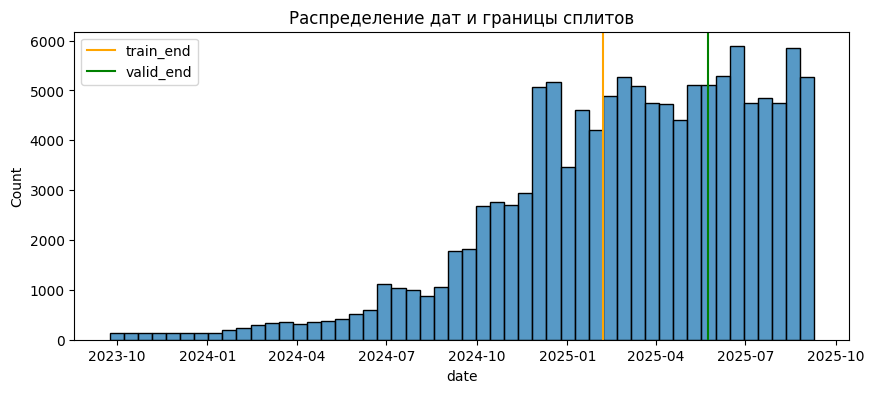

In [62]:
plt.figure(figsize=(10,4))
sns.histplot(msgs_targets['date'], bins=50)
plt.axvline(train_end, color='orange', label='train_end')
plt.axvline(valid_end, color='green', label='valid_end')
plt.legend()
plt.title("Распределение дат и границы сплитов")
plt.show()

In [63]:
train_df.to_csv(DATA_DIR / "train_ids.csv", index=False)
valid_df.to_csv(DATA_DIR / "valid_ids.csv", index=False)
test_df.to_csv(DATA_DIR / "test_ids.csv", index=False)

## Feature engineering


In [100]:
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

for part in [train_df, valid_df, test_df]:
    part['dayofweek_num'] = part['dayofweek'].map(day_map)

In [101]:
def parse_message_vector(s):
    """Парсит строку вида `'слово':11 'другоеслово':5` в dict {слово: count}."""
    if pd.isna(s) or not isinstance(s, str) or s.strip() == '':
        return {}
    pairs = re.findall(r"'([^']+)':(\d+)", s)
    return {token: int(cnt) for token, cnt in pairs}

In [102]:
train_dicts = train_df['message_vector'].apply(parse_message_vector).tolist()
valid_dicts = valid_df['message_vector'].apply(parse_message_vector).tolist()
test_dicts  = test_df['message_vector'].apply(parse_message_vector).tolist()

In [103]:
dv = DictVectorizer(sparse=True)
X_train_bow = dv.fit_transform(train_dicts)   # fit ONLY on train
X_val_bow   = dv.transform(valid_dicts)       # transform
X_test_bow  = dv.transform(test_dicts)        # transform

## Бейзлайн-модели

In [104]:
svd = TruncatedSVD(n_components=100, random_state=42)

X_train_emb = svd.fit_transform(X_train_bow)  # fit ONLY on train
X_val_emb   = svd.transform(X_val_bow)        # transform
X_test_emb  = svd.transform(X_test_bow)       # transform


emb_cols = [f'emb_{i}' for i in range(X_train_emb.shape[1])]

train_emb_df = pd.DataFrame(X_train_emb, columns=emb_cols, index=train_df.index)
valid_emb_df = pd.DataFrame(X_val_emb, columns=emb_cols, index=valid_df.index)
test_emb_df  = pd.DataFrame(X_test_emb,  columns=emb_cols, index=test_df.index)

train_df = pd.concat([train_df, train_emb_df], axis=1)
valid_df = pd.concat([valid_df, valid_emb_df], axis=1)
test_df  = pd.concat([test_df,  test_emb_df],  axis=1)

In [105]:
test_df.head()

,id,id_channel,date,message_vector,text_len,word_count,hour,dayofweek,views_h24,views_h48,...,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99
17655,f1a371b4-9edb-42f7-9c18-2f3b75eb0d49,5,2025-08-11 18:23:20+00:00,'2021':14 '4350':16 'bloomberg':17 'ethereum':...,133,18,18,Monday,67558.0,54427.0,...,0.749153,-1.021627,-0.385622,1.368323,-1.810126,0.657624,1.105611,-0.938618,1.966323,0.267467
17705,4c025a82-ab3b-40da-8a78-a68b1c12e19f,5,2025-08-11 18:09:13+00:00,'17':1 '5':2 'bloomberg':14 'артем':9 'внуков'...,93,14,18,Monday,78217.0,62586.0,...,-1.144010,-0.368389,0.192180,0.190354,-1.464017,0.659669,0.415627,-0.063353,0.748947,0.407957
17727,9294523c-c77c-40b5-910a-70e170f502ec,5,2025-08-11 15:05:14+00:00,'bloomberg':13 'ед':4 'путин':11 'пятниц':2 'р...,80,15,15,Monday,83900.0,58122.0,...,-0.694169,-0.604357,0.276986,0.768093,-0.462985,0.477818,0.217567,-0.597059,1.352684,0.123753
36724,8208e447-617e-43a5-bb3e-f035a12330cb,3,2025-06-20 12:57:14+00:00,'16':6 '6':10 '9':9 'годов':1 'заяв':14 'инфля...,105,14,12,Friday,740576.0,421263.0,...,2.673090,0.432965,1.858233,-0.640455,0.773922,1.908234,0.706887,1.431352,-0.610504,1.621328
36748,40bf24a9-6fa6-41d3-921b-0fbb05f89e84,4,2025-06-20 08:49:40+00:00,'bankrollo':14 'глав':11 'егор':13 'заяв':10 '...,103,14,8,Friday,178841.0,95713.0,...,1.065311,-1.192200,-0.365937,-0.343214,-1.203807,0.407967,1.673470,-0.251919,1.375940,0.536041


In [113]:
feature_cols = emb_cols + [
    'text_len',
    'word_count',
    'hour',
    'dayofweek_num',
    # 'id_channel',
]

target_col = 'viral'

In [114]:
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(int)

X_val = valid_df[feature_cols].copy()
y_val = valid_df[target_col].astype(int)

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(int)

# на всякий случай всё в числа + заполнить NaN
for X in [X_train, X_val, X_test]:
    X[:] = X.apply(pd.to_numeric, errors='coerce')

In [115]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val, label=y_val)

In [116]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.848082	valid's auc: 0.699984
[100]	train's auc: 0.893275	valid's auc: 0.705672
[150]	train's auc: 0.923279	valid's auc: 0.707394
[200]	train's auc: 0.943705	valid's auc: 0.708548
[250]	train's auc: 0.960678	valid's auc: 0.708713
Early stopping, best iteration is:
[245]	train's auc: 0.959679	valid's auc: 0.709322


In [117]:
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

print("VAL AUC-ROC:", roc_auc_score(y_val, y_pred_val))
print("VAL AUC-PR :", average_precision_score(y_val, y_pred_val))
print("TEST AUC-ROC:", roc_auc_score(y_test, y_pred_test))
print("TEST AUC-PR :", average_precision_score(y_test, y_pred_test))

VAL AUC-ROC: 0.709321520051319
VAL AUC-PR : 0.2049010172580969
TEST AUC-ROC: 0.7128206372464972
TEST AUC-PR : 0.2300888191890085


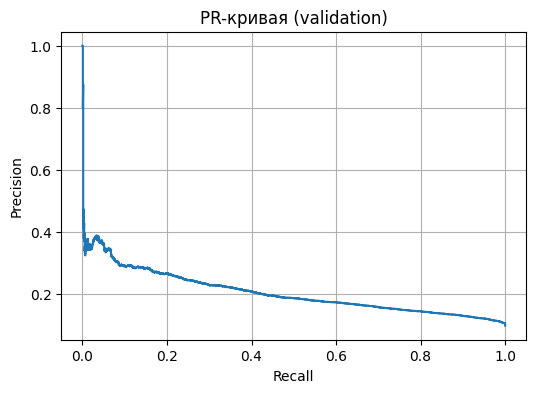

In [118]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_val, y_pred_val)
plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-кривая (validation)")
plt.grid(True)
plt.show()

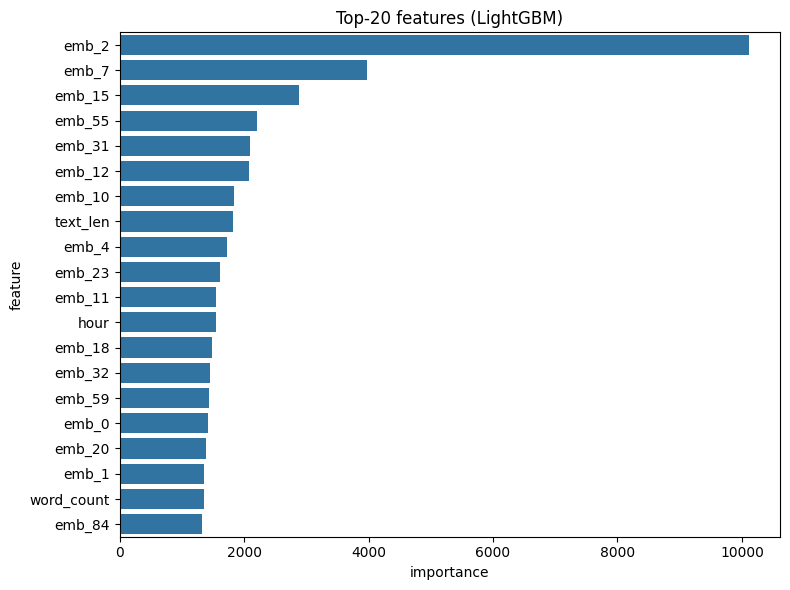

In [119]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importances.head(20), x="importance", y="feature")
plt.title("Top-20 features (LightGBM)")
plt.tight_layout()
plt.show()

In [126]:
def precision_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    """
    Precision@K: доля положительных среди top-K прогнозов.
    """
    if k <= 0:
        raise ValueError("k must be positive")

    k = min(k, len(y_true))
    top_k_idx = np.argsort(y_pred)[-k:][::-1]
    return y_true[top_k_idx].sum() / k

In [130]:
def recall_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    """
    Recall@K: доля найденных положительных среди всех положительных.
    """
    if k <= 0:
        raise ValueError("k must be positive")

    k = min(k, len(y_true))
    top_k_idx = np.argsort(y_pred)[-k:][::-1]

    total_positive = y_true.sum()
    if total_positive == 0:
        return 0.0

    return y_true[top_k_idx].sum() / total_positive

In [131]:
k_values = [50, 100, 200]

print("=== Validation metrics @K ===")
for k in k_values:
    p_k = precision_at_k(y_val.values, y_pred_val, k)
    r_k = recall_at_k(y_val.values, y_pred_val, k)
    print(f"K={k:3d} | Precision@K={p_k:.4f} | Recall@K={r_k:.4f}")

=== Validation metrics @K ===
K= 50 | Precision@K=0.3800 | Recall@K=0.0053
K=100 | Precision@K=0.3500 | Recall@K=0.0097
K=200 | Precision@K=0.3500 | Recall@K=0.0194


In [ ]:


def calibrate_threshold(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    metric: str = "f1"
):
    """
    Подбор порога по PR-кривой.
    
    metric:
        - "f1"       → максимизация F1
        - "precision"→ максимизация precision
        - "recall"   → максимизация recall
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)

    # precision_recall_curve возвращает thresholds длиной N-1
    thresholds = np.append(thresholds, 1.0)

    if metric == "f1":
        scores = 2 * precision * recall / (precision + recall + 1e-12)
    elif metric == "precision":
        scores = precision
    elif metric == "recall":
        scores = recall
    else:
        raise ValueError("metric must be one of ['f1', 'precision', 'recall']")

    best_idx = np.argmax(scores)
    best_threshold = thresholds[best_idx]

    y_bin = (y_pred >= best_threshold).astype(int)

    metrics = {
        "threshold": float(best_threshold),
        "precision": precision_score(y_true, y_bin),
        "recall": recall_score(y_true, y_bin),
        "f1": f1_score(y_true, y_bin),
    }

    return best_threshold, metrics

In [133]:
threshold, threshold_metrics = calibrate_threshold(
    y_val.values,
    y_pred_val,
    metric="f1"
)

In [134]:
print("\nOptimal threshold:", threshold)
print("Threshold metrics:", threshold_metrics)


Optimal threshold: 0.13614176815193418
Threshold metrics: {'threshold': 0.13614176815193418, 'precision': 0.2106044853705629, 'recall': 0.393670183231538, 'f1': 0.2744073536526367}
